## Level 4 – Weather-Driven Highway Accidents

## Problem Statement

Supervised regression problem. We aim to predict the daily number of road accidents on highways using meteorological data. The objective is to help Grupo Brisa manage emergency vehicle allocation, where 3 vehicles are needed per accident.

**Why this is supervised learning**
- Labeled target values (daily accident counts per location)
- Clear prediction target and measurable error metric
- Historical weather-to-accident relationships used to predict future outcomes

**Prediction Task:** Given daily weather features (temperature, humidity, rainfall, wind, pressure, etc.) for a location and date, predict the number of accidents.

**Evaluation Metric (Vehicle Error):**
Vehicle Error = |3 x actual_accidents - predicted_vehicles|

Predicted_vehicles is the model's predicted accident count x 3. This metric penalizes both overestimation (too many vehicles sent) and underestimation (insufficient response). For safety, underestimation is treated as higher risk.

**Data Overview:**
- **Accidents Dataset**: Daily accident counts per location (18 districts, from 2025-12-29 to 2026-03-05)
- **Meteorology Dataset**: Hourly weather measurements per location (starting 2025-03-05; temperature, humidity, rain, wind, pressure, etc.)
- **Objective**: Aggregate hourly weather to daily level and align periods by location/date

**Approach:**
1. Load and explore datasets
2. Align temporal ranges and aggregate hourly weather to daily
3. Perform EDA (correlations, distributions, outliers)
4. Engineer features from EDA evidence
5. Apply chronological train-validation-test logic
6. Train linear baseline and controlled variants
7. Evaluate with Vehicle Error
8. Summarize conclusions and next improvements

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import warnings
warnings.filterwarnings('ignore')

# Plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Data paths
accidents_path = Path("../data/accidents_dataset.csv")
meteorology_path = Path("../data/meteorology_dataset_with_snow_fall.csv")

In [23]:
# Load datasets
accidents_df = pd.read_csv(accidents_path)
meteorology_df = pd.read_csv(meteorology_path)

print("ACCIDENTS DATASET")
print("=" * 80)
print(f"Shape: {accidents_df.shape}")
print(f"Columns: {list(accidents_df.columns)}")
print(accidents_df.head(3).to_string(index=False))

ACCIDENTS DATASET
Shape: (1206, 3)
Columns: ['location', 'accidents', 'time']
location  accidents       time
  Aveiro         36 2025-12-29
    Beja          7 2025-12-29
   Braga         22 2025-12-29


In [24]:
print("\nMETEOROLOGY DATASET")
print("=" * 80)
print(f"Shape: {meteorology_df.shape}")
print(f"Columns: {len(meteorology_df.columns)} features")
print(meteorology_df.head(3).to_string(index=False))


METEOROLOGY DATASET
Shape: (158112, 18)
Columns: 18 features
location                time  temperature_2m  relative_humidity_2m  dew_point_2m  rain  cloud_cover  cloud_cover_low  cloud_cover_mid  cloud_cover_highh  wind_speed_10m  wind_direction_10m  wind_gusts_10m  wind_direction_100m  wind_speed_100m  pressure_msl  surface_pressure  snow_fall
  Aveiro 2025-03-05 00:00:00            11.6                    79           8.1   0.0           31                0               31                  0             4.5                  92             9.0                   99             15.7        1013.9            1012.8          0
  Aveiro 2025-03-05 01:00:00            11.2                    90           9.6   0.0           87                9               85                 45            18.6                 160            29.5                  160             27.6        1014.8            1013.7          0
  Aveiro 2025-03-05 02:00:00            11.1                    90           9.6

In [25]:
# Check temporal ranges and data alignment
accidents_df['time'] = pd.to_datetime(accidents_df['time'])
meteorology_df['time'] = pd.to_datetime(meteorology_df['time'])

acc_start, acc_end = accidents_df['time'].min(), accidents_df['time'].max()
met_start, met_end = meteorology_df['time'].min(), meteorology_df['time'].max()

print("\nDATA ALIGNMENT & TEMPORAL RANGES")
print("=" * 80)
print(f"Accidents range:   {acc_start} -> {acc_end}")
print(f"Meteorology range: {met_start} -> {met_end}")
print(f"Accident locations: {accidents_df['location'].nunique()} | Meteorology locations: {meteorology_df['location'].nunique()}")
print(f"Meteorology starts before accidents: {met_start < acc_start}")
print(f"Days trimmed from meteorology: {(acc_start - met_start).days}")


DATA ALIGNMENT & TEMPORAL RANGES
Accidents range:   2025-12-29 00:00:00 -> 2026-03-05 00:00:00
Meteorology range: 2025-03-05 00:00:00 -> 2026-03-05 23:00:00
Accident locations: 18 | Meteorology locations: 18
Meteorology starts before accidents: True
Days trimmed from meteorology: 299


## Phase 2: Data Preparation & Alignment

### Step 1: Trim and Aggregate Meteorology Data

As the meteorology dataset starts in March 2025, but accident data only begins on 2025-12-29. We need to:
1. Remove all meteorology data before the first accident date
2. Aggregate hourly weather measurements to daily statistics (mean, max, min when appropriate)
3. Align both datasets by location and date for merging

This aggregation is justified by the task: we want to predict daily accidents from daily weather patterns. The loss of information is justified by the proportional gains in predictive power.

In [26]:
# Trim meteorology data to match accidents interval
cutoff_date = accidents_df['time'].min()
meteorology_df_trimmed = meteorology_df[meteorology_df['time'] >= cutoff_date].copy()

print("METEOROLOGY DATA TRIMMING")
print("=" * 80)
print(f"Original rows: {len(meteorology_df)}")
print(f"Trimmed rows:  {len(meteorology_df_trimmed)}")
print(f"Date range after trim: {meteorology_df_trimmed['time'].min()} -> {meteorology_df_trimmed['time'].max()}")

METEOROLOGY DATA TRIMMING
Original rows: 158112
Trimmed rows:  28944
Date range after trim: 2025-12-29 00:00:00 -> 2026-03-05 23:00:00


In [27]:
# Step 2: Aggregate hourly to daily meteorology data
meteorology_df_trimmed.columns = meteorology_df_trimmed.columns.str.strip()
meteorology_df_trimmed['date'] = meteorology_df_trimmed['time'].dt.date

aggregation_ops = {
    'temperature_2m': 'mean',
    'relative_humidity_2m': 'mean',
    'dew_point_2m': 'mean',
    'rain': 'sum',
    'cloud_cover': 'mean',
    'cloud_cover_low': 'mean',
    'cloud_cover_mid': 'mean',
    'cloud_cover_highh': 'mean',
    'wind_speed_10m': 'mean',
    'wind_direction_10m': 'mean',
    'wind_gusts_10m': 'mean',
    'wind_direction_100m': 'mean',
    'wind_speed_100m': 'mean',
    'pressure_msl': 'mean',
    'surface_pressure': 'mean'
}

if 'snow_fall' in meteorology_df_trimmed.columns:
    aggregation_ops['snow_fall'] = 'max'

meteorology_daily = meteorology_df_trimmed.groupby(['location', 'date']).agg(aggregation_ops).reset_index()
meteorology_daily['date'] = pd.to_datetime(meteorology_daily['date'])

print('METEOROLOGY DAILY AGGREGATION')
print('=' * 80)
print(f"Shape: {meteorology_daily.shape}")
print(f"Locations: {meteorology_daily['location'].nunique()} | Days: {meteorology_daily['date'].nunique()}")
print(f"Date range: {meteorology_daily['date'].min()} -> {meteorology_daily['date'].max()}")
print(f"Snow column present: {'snow_fall' in meteorology_daily.columns}")

METEOROLOGY DAILY AGGREGATION
Shape: (1206, 18)
Locations: 18 | Days: 67
Date range: 2025-12-29 00:00:00 -> 2026-03-05 00:00:00
Snow column present: True


In [28]:
# Step 3: Prepare accidents dataset and merge with meteorology data
accidents_df['date'] = pd.to_datetime(accidents_df['time'].dt.date)
accidents_df.rename(columns={'accidents': 'accident_count'}, inplace=True)

merged_df = pd.merge(
    accidents_df[['location', 'date', 'accident_count']],
    meteorology_daily,
    on=['location', 'date'],
    how='inner'
 )

if 'snow_fall' not in merged_df.columns:
    merged_df['snow_fall'] = 0.0
merged_df['snow_fall'] = merged_df['snow_fall'].fillna(0.0)

print('DATASET MERGING')
print('=' * 80)
print(f"Merged shape: {merged_df.shape}")
print(f"Locations: {merged_df['location'].nunique()} | Days: {merged_df['date'].nunique()}")
print(f"Date range: {merged_df['date'].min()} -> {merged_df['date'].max()}")
print(f"Snow non-zero rows: {(merged_df['snow_fall'] > 0).sum()}")

DATASET MERGING
Merged shape: (1206, 19)
Locations: 18 | Days: 67
Date range: 2025-12-29 00:00:00 -> 2026-03-05 00:00:00
Snow non-zero rows: 26


In [29]:
# Step 4: Analyze missing values
missing_counts = merged_df.isnull().sum()
missing_pct = (missing_counts / len(merged_df)) * 100

missing_summary = pd.DataFrame({
    'Column': missing_counts.index,
    'Missing Count': missing_counts.values,
    'Missing %': missing_pct.values
})
missing_summary = missing_summary[missing_summary['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print("\nMISSING VALUES ANALYSIS")
print("=" * 80)
if len(missing_summary) > 0:
    print(missing_summary.to_string(index=False))
else:
    print("No missing values detected in merged dataset.")

print(f"Dataset dimensions: {merged_df.shape[0]} rows, {merged_df.shape[1]} columns")
print(f"Usable feature columns: {merged_df.shape[1] - 2} (excluding location/date)")


MISSING VALUES ANALYSIS
No missing values detected in merged dataset.
Dataset dimensions: 1206 rows, 19 columns
Usable feature columns: 17 (excluding location/date)


## Phase 3: Exploratory Data Analysis

### Understanding the Data Distribution

In this phase, we visualize the accident counts, weather features, and their relationships. This graphical evidence will guide our feature engineering decisions later. Each visualization answers a specific question:

1. **Accident Distribution**: How many accidents occur daily? Are there outliers?
2. **Weather Patterns**: What is the range and variation of weather features?
3. **Correlation Analysis**: Which weather features show visible relationships with accidents?
4. **Temporal Patterns**: Do accidents vary by date or location consistently?

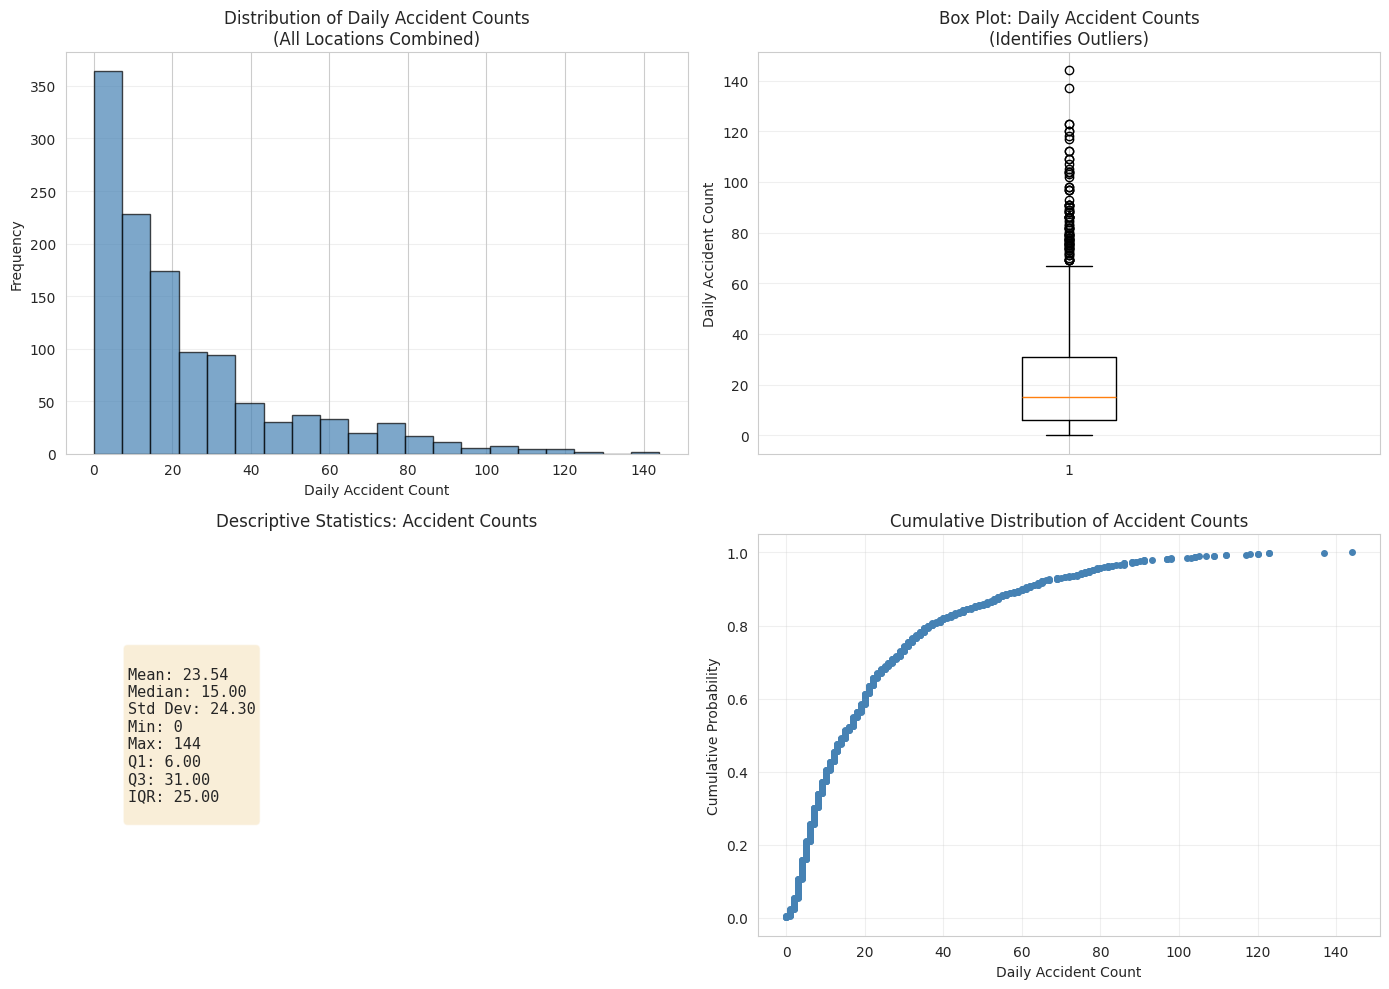

ACCIDENT COUNT STATISTICS
count    1206.000000
mean       23.539801
std        24.303537
min         0.000000
25%         6.000000
50%        15.000000
75%        31.000000
max       144.000000
Name: accident_count, dtype: float64


In [30]:
# Visualization 1: Accident Count Distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram of accident counts
axes[0, 0].hist(merged_df['accident_count'], bins=20, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Daily Accident Count')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Daily Accident Counts\n(All Locations Combined)')
axes[0, 0].grid(axis='y', alpha=0.3)

# Box plot to identify outliers
axes[0, 1].boxplot(merged_df['accident_count'], vert=True)
axes[0, 1].set_ylabel('Daily Accident Count')
axes[0, 1].set_title('Box Plot: Daily Accident Counts\n(Identifies Outliers)')
axes[0, 1].grid(axis='y', alpha=0.3)

# Descriptive statistics
stats_text = f"""
Mean: {merged_df['accident_count'].mean():.2f}
Median: {merged_df['accident_count'].median():.2f}
Std Dev: {merged_df['accident_count'].std():.2f}
Min: {merged_df['accident_count'].min():.0f}
Max: {merged_df['accident_count'].max():.0f}
Q1: {merged_df['accident_count'].quantile(0.25):.2f}
Q3: {merged_df['accident_count'].quantile(0.75):.2f}
IQR: {merged_df['accident_count'].quantile(0.75) - merged_df['accident_count'].quantile(0.25):.2f}
"""
axes[1, 0].text(0.1, 0.5, stats_text, fontsize=11, verticalalignment='center', 
                family='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
axes[1, 0].axis('off')
axes[1, 0].set_title('Descriptive Statistics: Accident Counts')

# Cumulative distribution
sorted_accidents = np.sort(merged_df['accident_count'])
cumulative = np.arange(1, len(sorted_accidents) + 1) / len(sorted_accidents)
axes[1, 1].plot(sorted_accidents, cumulative, marker='.', linestyle='none', markersize=8, color='steelblue')
axes[1, 1].set_xlabel('Daily Accident Count')
axes[1, 1].set_ylabel('Cumulative Probability')
axes[1, 1].set_title('Cumulative Distribution of Accident Counts')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("ACCIDENT COUNT STATISTICS")
print("="*80)
print(merged_df['accident_count'].describe())


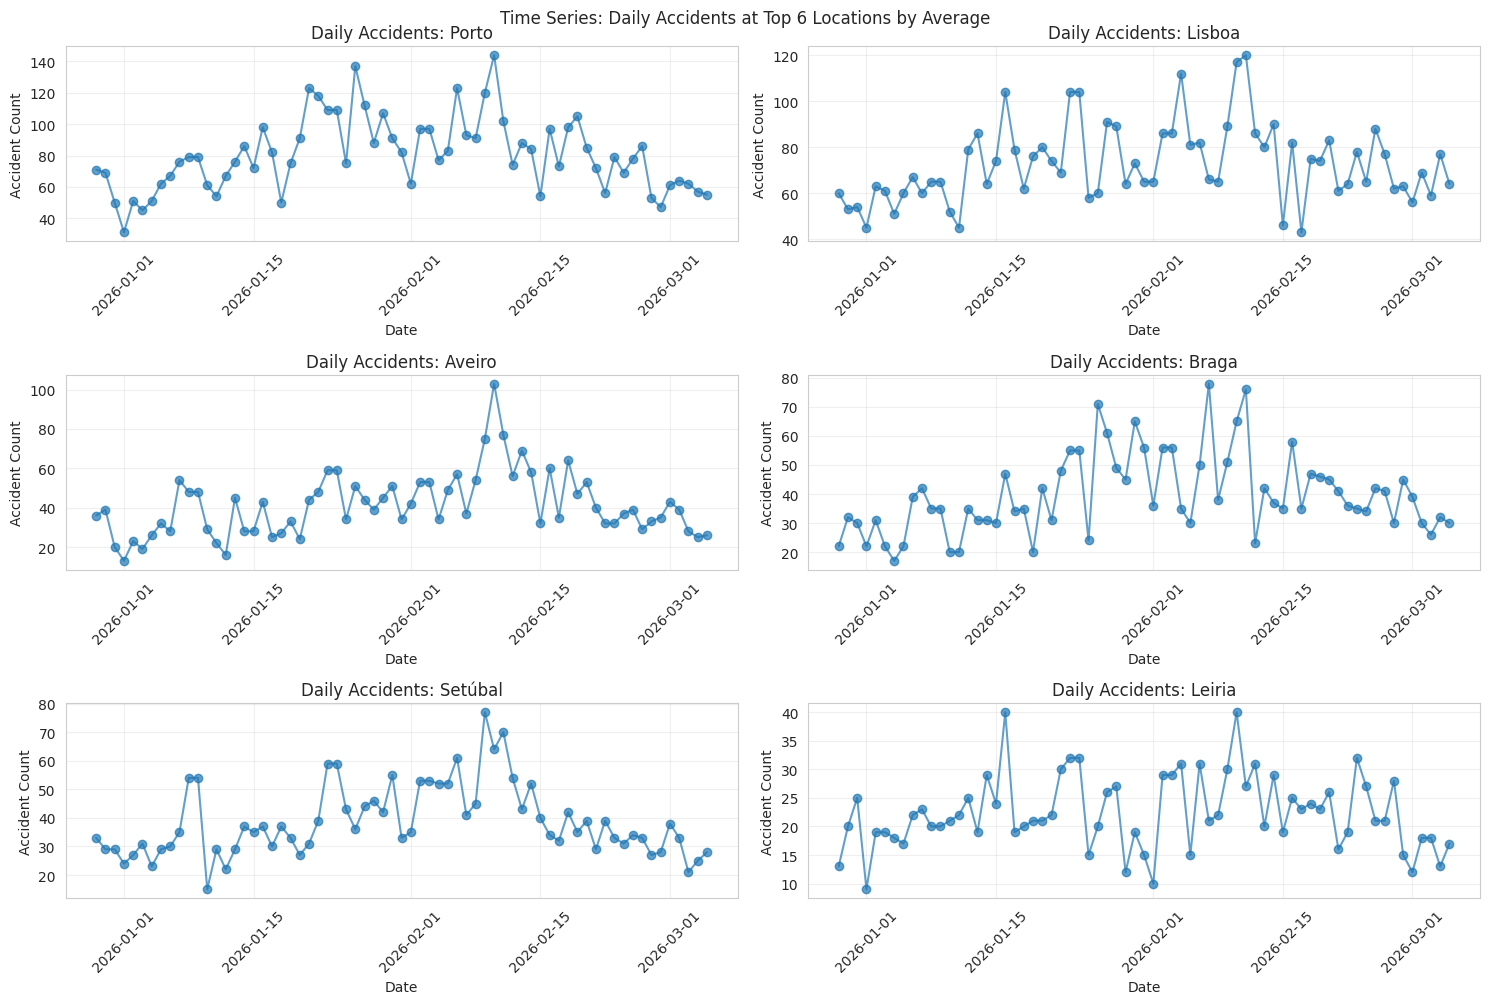

TOP 6 LOCATIONS BY AVERAGE DAILY ACCIDENTS
               mean        std  min  max  count
location                                       
Porto     80.298507  23.309521   31  144     67
Lisboa    72.641791  16.948855   43  120     67
Aveiro    41.194030  15.971792   13  103     67
Braga     39.611940  13.846513   17   78     67
Setúbal   38.641791  12.428830   15   77     67
Leiria    22.358209   6.496389    9   40     67


In [31]:
# Visualization 2: Time Series of Accidents by Location
# Select a subset of locations for clarity (top 6 by mean accidents)
top_locations = merged_df.groupby('location')['accident_count'].mean().nlargest(6).index.tolist()

fig, axes = plt.subplots(3, 2, figsize=(15, 10))
axes = axes.flatten()

for idx, location in enumerate(top_locations):
    location_data = merged_df[merged_df['location'] == location].sort_values('date')
    axes[idx].plot(location_data['date'], location_data['accident_count'], marker='o', linestyle='-', label=location, alpha=0.7)
    axes[idx].set_title(f'Daily Accidents: {location}')
    axes[idx].set_xlabel('Date')
    axes[idx].set_ylabel('Accident Count')
    axes[idx].grid(alpha=0.3)
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.suptitle('Time Series: Daily Accidents at Top 6 Locations by Average', y=1.00, fontsize=12)
plt.show()

print("TOP 6 LOCATIONS BY AVERAGE DAILY ACCIDENTS")
print("="*80)
location_stats = merged_df.groupby('location')['accident_count'].agg(['mean', 'std', 'min', 'max', 'count'])
print(location_stats.sort_values('mean', ascending=False).head(6))


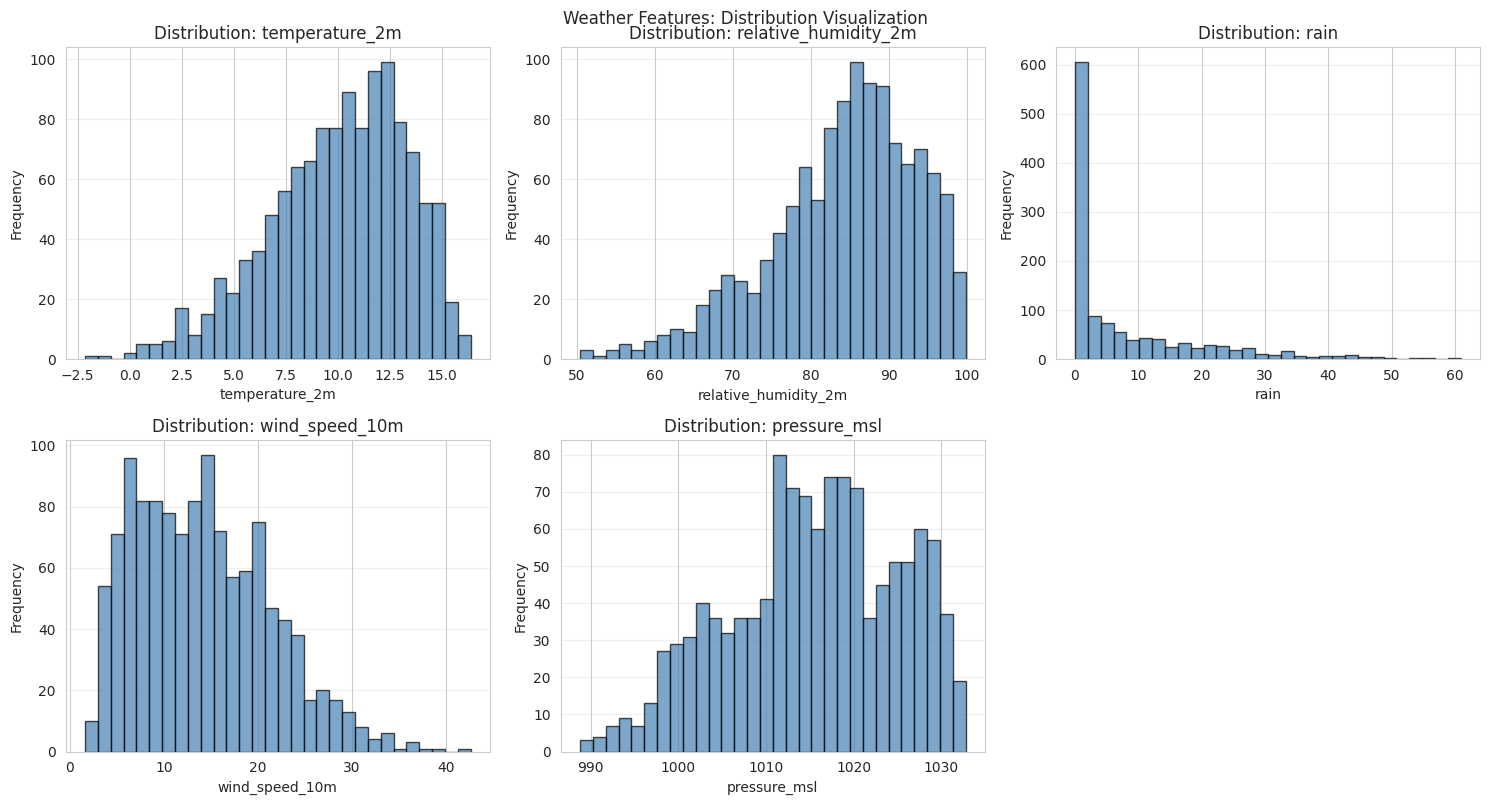

WEATHER FEATURES STATISTICS
       temperature_2m  relative_humidity_2m         rain  wind_speed_10m  \
count     1206.000000           1206.000000  1206.000000     1206.000000   
mean        10.068107             84.189849     8.019403       14.143619   
std          3.287970              9.422888    11.614916        7.166314   
min         -2.145833             50.375000     0.000000        1.625000   
25%          7.897917             78.750000     0.000000        8.236458   
50%         10.493750             85.645833     2.000000       13.529167   
75%         12.529167             91.281250    12.200000       19.238542   
max         16.404167             99.875000    60.900000       42.604167   

       pressure_msl  
count   1206.000000  
mean    1015.388740  
std        9.665182  
min      988.775000  
25%     1008.973958  
50%     1015.927083  
75%     1023.408333  
max     1032.775000  


In [32]:
# Visualization 3: Weather Feature Distributions
# Select key weather features for inspection
key_features = ['temperature_2m', 'relative_humidity_2m', 'rain', 'wind_speed_10m', 'pressure_msl']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, feature in enumerate(key_features):
    axes[idx].hist(merged_df[feature], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Frequency')
    axes[idx].set_title(f'Distribution: {feature}')
    axes[idx].grid(axis='y', alpha=0.3)

# Hide extra subplot
axes[5].axis('off')

plt.tight_layout()
plt.suptitle('Weather Features: Distribution Visualization', y=1.00, fontsize=12)
plt.show()

print("WEATHER FEATURES STATISTICS")
print("="*80)
print(merged_df[key_features].describe())


GLOBAL CORRELATION WITH ACCIDENT COUNT (Top Features)
surface_pressure       0.422992
temperature_2m         0.310885
dew_point_2m           0.278143
rain                   0.194143
wind_gusts_10m         0.160684
wind_speed_100m        0.159183
wind_speed_10m         0.154468
cloud_cover_mid        0.108195
wind_direction_100m    0.103303
wind_direction_10m     0.096096
Name: accident_count, dtype: float64

BOTTOM FEATURES (Negative Correlation)
cloud_cover             0.028843
cloud_cover_low        -0.024611
relative_humidity_2m   -0.033377
snow_fall              -0.057585
pressure_msl           -0.078025
Name: accident_count, dtype: float64


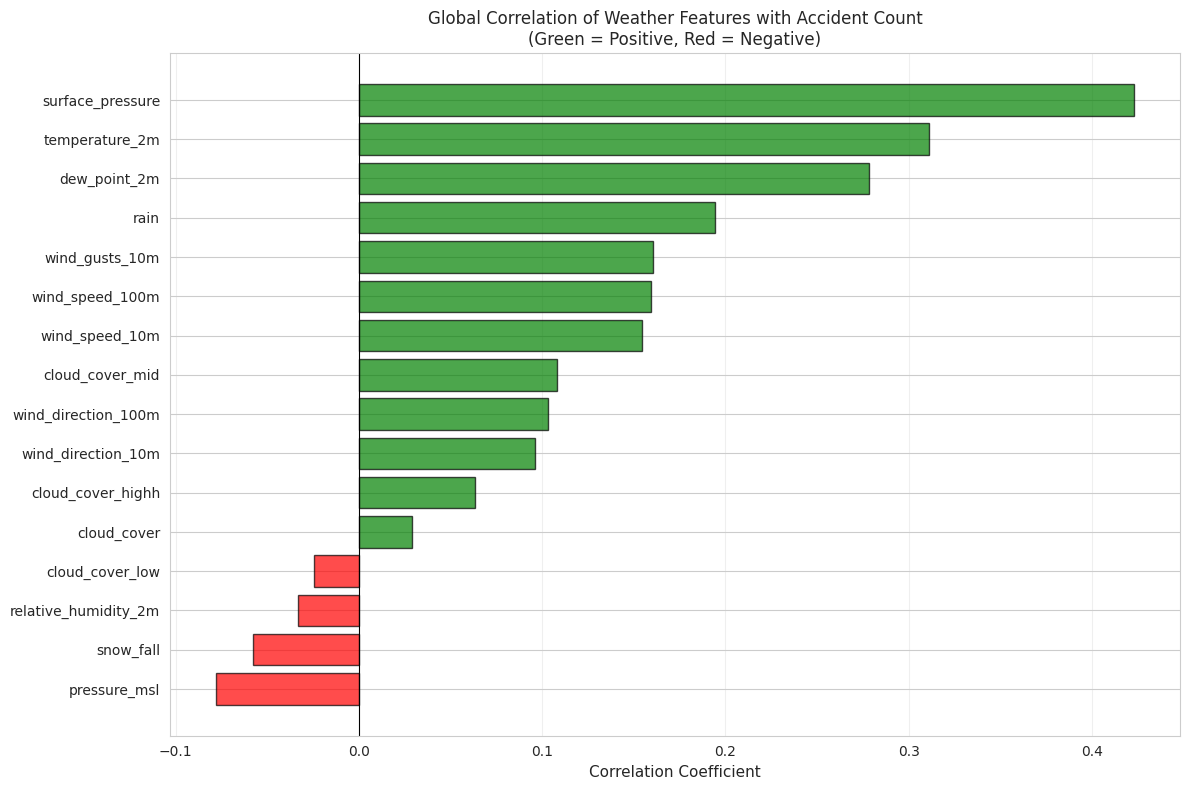

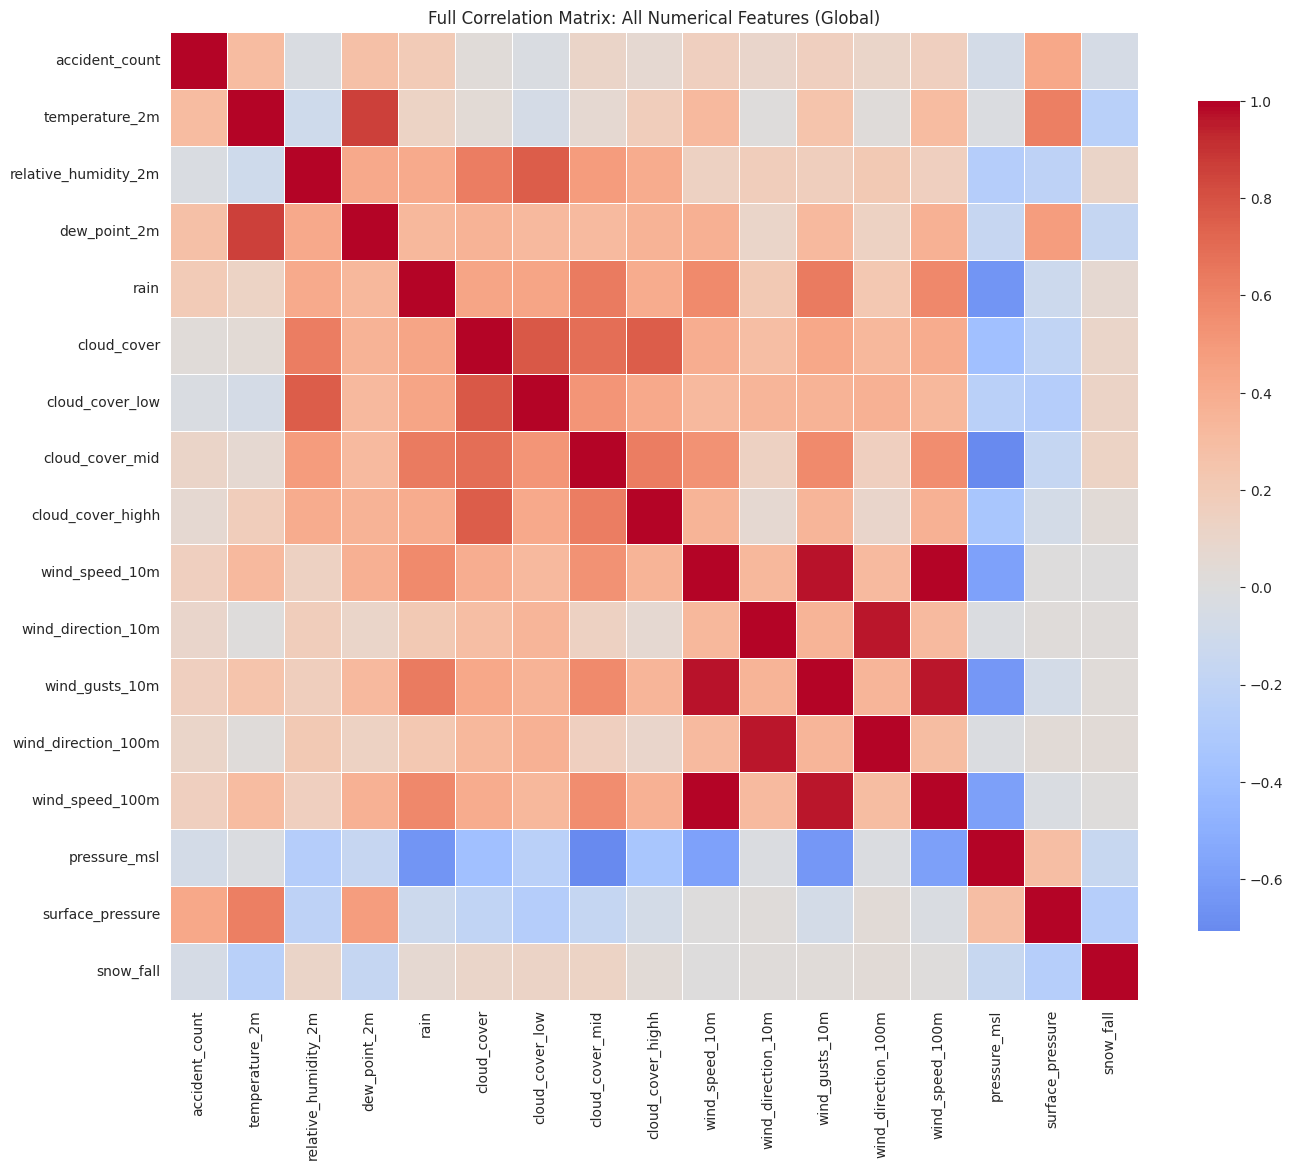

In [33]:
# Visualization 4: Global Correlation Overview (Weather Features vs Accidents)
# Note: this is a global view and may include regional composition effects.

# Select numerical columns (exclude location and date)
numerical_cols = merged_df.select_dtypes(include=[np.number]).columns.tolist()

# Calculate correlation matrix
correlation_matrix = merged_df[numerical_cols].corr()

# Extract correlations with accident_count
accident_correlations = correlation_matrix['accident_count'].drop('accident_count').sort_values(ascending=False)

print("GLOBAL CORRELATION WITH ACCIDENT COUNT (Top Features)")
print("="*80)
print(accident_correlations.head(10))
print("\nBOTTOM FEATURES (Negative Correlation)")
print(accident_correlations.tail(5))

# Visualize correlation bar chart
fig, ax = plt.subplots(figsize=(12, 8))
corr_df = pd.DataFrame(accident_correlations).sort_values('accident_count')
colors = ['red' if x < 0 else 'green' for x in corr_df['accident_count']]

ax.barh(range(len(corr_df)), corr_df['accident_count'], color=colors, alpha=0.7, edgecolor='black')
ax.set_yticks(range(len(corr_df)))
ax.set_yticklabels(corr_df.index, fontsize=10)
ax.set_xlabel('Correlation Coefficient', fontsize=11)
ax.set_title('Global Correlation of Weather Features with Accident Count\n(Green = Positive, Red = Negative)', fontsize=12)
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Full correlation matrix visualization (all numerical features)
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title('Full Correlation Matrix: All Numerical Features (Global)', fontsize=12)
plt.tight_layout()
plt.show()

## Phase 3B: Correlation Decomposition (Global vs Regional)

Goal: understand whether global weather-accident correlations are true within-region weather effects, or mostly composition effects driven by regional baseline traffic/population intensity.

GLOBAL VS REGION CORRELATION SUMMARY (TOP DIVERGENCES)
                      abs_global_minus_median  global_corr  median_region_corr
surface_pressure                        0.553        0.423              -0.130
temperature_2m                          0.310        0.311               0.000
cloud_cover_low                         0.177       -0.025               0.152
relative_humidity_2m                    0.129       -0.033               0.095
rain                                    0.117        0.194               0.311
snow_fall                               0.070       -0.058               0.012
wind_gusts_10m                          0.064        0.161               0.224


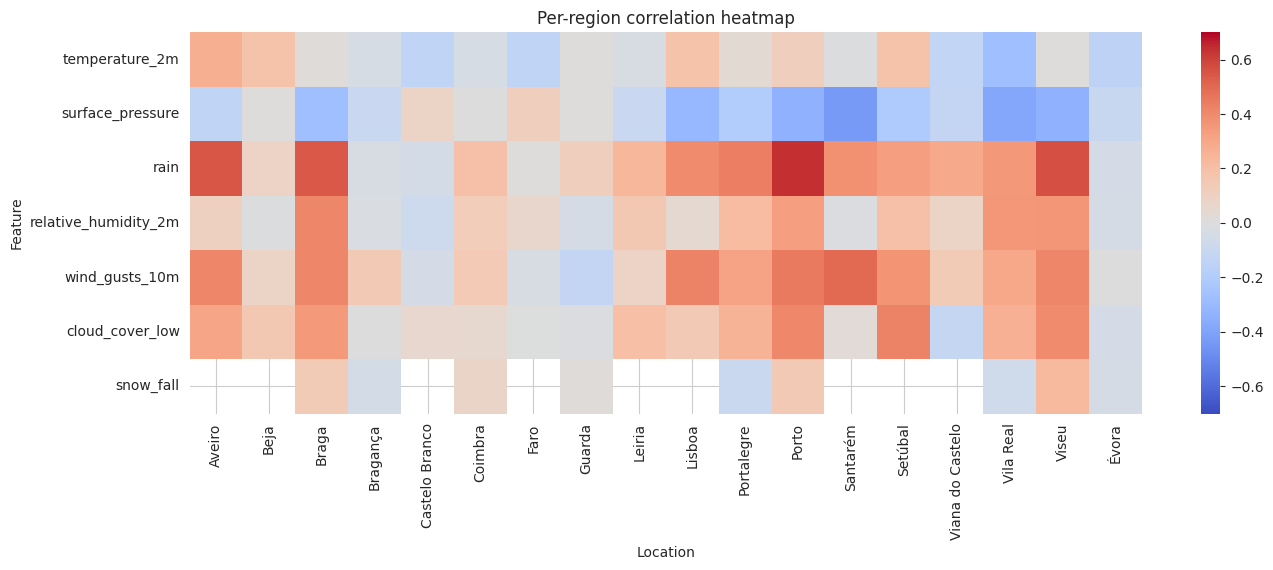

In [34]:
# Diagnostic 1: Global vs per-region correlation summary
selected_features = [
    'temperature_2m', 'surface_pressure', 'rain', 'relative_humidity_2m',
    'wind_gusts_10m', 'cloud_cover_low', 'snow_fall'
 ]
selected_features = [f for f in selected_features if f in merged_df.columns]

global_corr = merged_df[selected_features + ['accident_count']].corr()['accident_count'].drop('accident_count')

locations = sorted(merged_df['location'].unique())
region_corr = pd.DataFrame(index=selected_features, columns=locations, dtype=float)
for loc in locations:
    loc_df = merged_df[merged_df['location'] == loc]
    for feat in selected_features:
        if loc_df[feat].nunique() <= 1:
            region_corr.loc[feat, loc] = np.nan
        else:
            region_corr.loc[feat, loc] = loc_df[[feat, 'accident_count']].corr().iloc[0, 1]

region_summary = pd.DataFrame({
    'global_corr': global_corr,
    'median_region_corr': region_corr.median(axis=1),
    'mean_region_corr': region_corr.mean(axis=1),
    'share_positive_regions': (region_corr > 0).mean(axis=1),
    'share_negative_regions': (region_corr < 0).mean(axis=1)
}).sort_values('global_corr', ascending=False)
region_summary['global_minus_median'] = region_summary['global_corr'] - region_summary['median_region_corr']

print('GLOBAL VS REGION CORRELATION SUMMARY (TOP DIVERGENCES)')
print('=' * 90)
print(
    region_summary['global_minus_median'].abs()
    .sort_values(ascending=False)
    .head(7)
    .to_frame('abs_global_minus_median')
    .join(region_summary[['global_corr', 'median_region_corr']])
    .round(3)
    .to_string()
 )

fig, ax = plt.subplots(figsize=(14, 5.8))
sns.heatmap(region_corr, cmap='coolwarm', center=0, vmin=-0.7, vmax=0.7, ax=ax)
ax.set_title('Per-region correlation heatmap')
ax.set_xlabel('Location')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

In [35]:
# Diagnostic 2: Between-region vs within-region decomposition for key features
focus_features = [f for f in ['temperature_2m', 'surface_pressure', 'rain'] if f in merged_df.columns]

region_means = merged_df.groupby('location')[focus_features + ['accident_count']].mean()
between_corr = region_means.corr()['accident_count'].drop('accident_count')

demeaned_df = merged_df.copy()
for col in focus_features + ['accident_count']:
    demeaned_df[col] = demeaned_df[col] - demeaned_df.groupby('location')[col].transform('mean')
within_corr = demeaned_df[focus_features + ['accident_count']].corr()['accident_count'].drop('accident_count')

global_focus = merged_df[focus_features + ['accident_count']].corr()['accident_count'].drop('accident_count')

decomp_table = pd.DataFrame({
    'global_corr': global_focus,
    'between_region_corr': between_corr,
    'within_region_corr': within_corr
}).round(4)
decomp_table['between_minus_within'] = (
    decomp_table['between_region_corr'] - decomp_table['within_region_corr']
).round(4)

print('CORRELATION DECOMPOSITION (GLOBAL / BETWEEN / WITHIN)')
print('=' * 90)
print(decomp_table.to_string())

CORRELATION DECOMPOSITION (GLOBAL / BETWEEN / WITHIN)
                  global_corr  between_region_corr  within_region_corr  between_minus_within
temperature_2m         0.3109               0.4739              0.0449                0.4290
surface_pressure       0.4230               0.5041             -0.1762                0.6803
rain                   0.1941               0.2744              0.3465               -0.0721


SNOW EFFECT SUMMARY
Global corr(snow_fall, accident_count): -0.0576
Locations with any snow days: 9 / 18
Weighted within-location snow effect: 2.2681
Controlled (location + temp-bin) effect: 2.7308

Top snow-effect locations (absolute delta):
  location  n_snow  delta_snow_minus_no_snow
     Porto       1                    29.136
     Braga       1                    15.621
     Viseu       2                     9.631
   Coimbra       2                     2.554
Portalegre       1                    -1.909
  Bragança       3                    -1.432
 Vila Real       3                    -1.333
     Évora       1                    -0.970


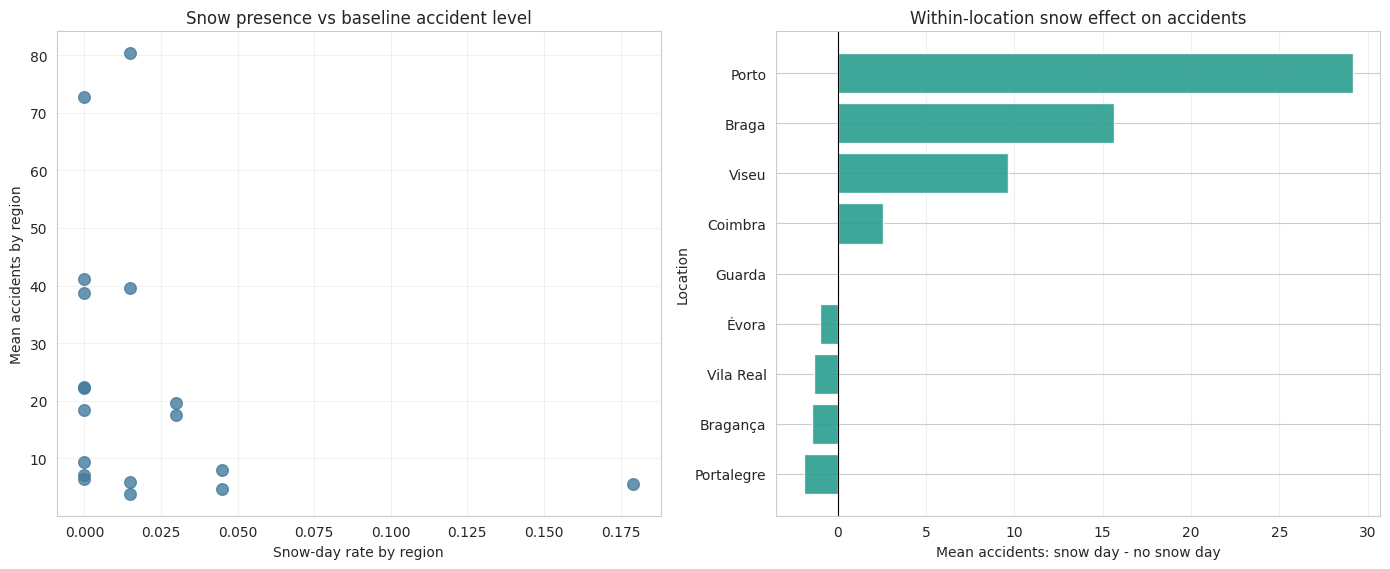

In [36]:
# Diagnostic 3: Snow paradox check (global vs within-location effect)
snow_global_corr = merged_df[['snow_fall', 'accident_count']].corr().iloc[0, 1]

loc_snow = merged_df.groupby('location').agg(
    mean_accidents=('accident_count', 'mean'),
    snow_days=('snow_fall', lambda s: int((s > 0).sum())),
    snow_rate=('snow_fall', lambda s: (s > 0).mean()),
    mean_snow_amount=('snow_fall', 'mean')
).sort_values('mean_accidents', ascending=False)

snow_locs = loc_snow[loc_snow['snow_days'] > 0].index.tolist()

snow_effect_rows = []
for loc in snow_locs:
    d = merged_df[merged_df['location'] == loc].copy()
    snow_days = d[d['snow_fall'] > 0]['accident_count']
    no_snow_days = d[d['snow_fall'] == 0]['accident_count']
    if len(snow_days) == 0 or len(no_snow_days) == 0:
        continue
    snow_effect_rows.append({
        'location': loc,
        'n_snow': len(snow_days),
        'delta_snow_minus_no_snow': snow_days.mean() - no_snow_days.mean()
    })

snow_effect_df = pd.DataFrame(snow_effect_rows).sort_values('delta_snow_minus_no_snow', ascending=False)

if len(snow_effect_df) > 0:
    weighted_delta = np.average(
        snow_effect_df['delta_snow_minus_no_snow'],
        weights=snow_effect_df['n_snow']
    )
else:
    weighted_delta = np.nan

snow_control_df = merged_df.copy()
snow_control_df['temp_bin'] = pd.qcut(
    snow_control_df['temperature_2m'], q=4, duplicates='drop', labels=False
)

control_rows = []
for (loc, tb), g in snow_control_df.groupby(['location', 'temp_bin']):
    a = g[g['snow_fall'] > 0]['accident_count']
    b = g[g['snow_fall'] == 0]['accident_count']
    if len(a) > 0 and len(b) > 0:
        control_rows.append({
            'location': loc,
            'temp_bin': tb,
            'n_snow': len(a),
            'delta': a.mean() - b.mean()
        })

control_df = pd.DataFrame(control_rows)
controlled_delta = np.average(control_df['delta'], weights=control_df['n_snow']) if len(control_df) else np.nan

print('SNOW EFFECT SUMMARY')
print('=' * 90)
print(f'Global corr(snow_fall, accident_count): {snow_global_corr:.4f}')
print(f'Locations with any snow days: {len(snow_locs)} / {loc_snow.shape[0]}')
print(f'Weighted within-location snow effect: {weighted_delta:.4f}')
print(f'Controlled (location + temp-bin) effect: {controlled_delta:.4f}')

if len(snow_effect_df) > 0:
    display_cols = ['location', 'n_snow', 'delta_snow_minus_no_snow']
    print('\nTop snow-effect locations (absolute delta):')
    print(
        snow_effect_df.assign(abs_delta=snow_effect_df['delta_snow_minus_no_snow'].abs())
        .sort_values('abs_delta', ascending=False)[display_cols]
        .head(8)
        .round(3)
        .to_string(index=False)
    )

fig, axes = plt.subplots(1, 2, figsize=(14, 5.8))

axes[0].scatter(loc_snow['snow_rate'], loc_snow['mean_accidents'], s=70, alpha=0.8, color='#457b9d')
axes[0].set_xlabel('Snow-day rate by region')
axes[0].set_ylabel('Mean accidents by region')
axes[0].set_title('Snow presence vs baseline accident level')
axes[0].grid(alpha=0.25)

if len(snow_effect_df) > 0:
    plot_snow = snow_effect_df.sort_values('delta_snow_minus_no_snow')
    axes[1].barh(plot_snow['location'], plot_snow['delta_snow_minus_no_snow'], color='#2a9d8f', alpha=0.9)
    axes[1].axvline(0, color='black', linewidth=0.8)
    axes[1].set_title('Within-location snow effect on accidents')
    axes[1].set_xlabel('Mean accidents: snow day - no snow day')
    axes[1].set_ylabel('Location')
    axes[1].grid(axis='x', alpha=0.3)
else:
    axes[1].text(0.5, 0.5, 'No comparable snow/non-snow samples', ha='center', va='center')
    axes[1].axis('off')

plt.tight_layout()
plt.show()

## Phase 4: Feature Engineering (Weather Effect with Proper Controls)

We keep weather as the core explanatory signal, while adding control variables that prevent false attribution:
- Temporal controls (`day_of_week`, `month`, `is_weekend`) capture normal traffic cycles.
- Spatial control (`location` one-hot) captures baseline regional differences.
- Snow is represented as `has_snow` (0/1), matching the available data values.

In [37]:
# Build modeling table with controlled features
model_df = merged_df.copy().sort_values(['date', 'location']).reset_index(drop=True)

# Temporal controls
model_df['day_of_week'] = model_df['date'].dt.dayofweek
model_df['month'] = model_df['date'].dt.month
model_df['is_weekend'] = (model_df['day_of_week'] >= 5).astype(int)

# Snow as binary indicator (dataset effectively contains 0/1)
model_df['has_snow'] = (model_df['snow_fall'] > 0).astype(int)

# Weather features (exclude target/date and keep numerics)
exclude_cols = {'accident_count', 'date', 'location', 'snow_fall'}
weather_cols = [
    c for c in model_df.select_dtypes(include=[np.number]).columns
    if c not in exclude_cols and c not in {'day_of_week', 'month', 'is_weekend', 'has_snow'}
]

# Keep core weather set if available, otherwise fallback to numeric weather columns
core_cols = [
    'temperature_2m', 'relative_humidity_2m', 'rain', 'wind_speed_10m',
    'wind_gusts_10m', 'pressure_msl', 'surface_pressure',
    'cloud_cover', 'cloud_cover_low', 'cloud_cover_mid', 'cloud_cover_highh'
]
core_cols = [c for c in core_cols if c in model_df.columns]
weather_cols = sorted(set(core_cols) | set(weather_cols))

base_feature_cols = weather_cols + ['has_snow', 'day_of_week', 'month', 'is_weekend']

# Global model features include one-hot location to account for baseline regional differences
model_df_global = pd.get_dummies(
    model_df[['location', 'date', 'accident_count'] + base_feature_cols],
    columns=['location'],
    drop_first=False,
    dtype=float
)

global_features = [c for c in model_df_global.columns if c not in ['date', 'accident_count']]
regional_features = base_feature_cols.copy()

print('FEATURE ENGINEERING SUMMARY')
print('=' * 90)
print(f'Rows: {model_df.shape[0]} | Locations: {model_df["location"].nunique()} | Dates: {model_df["date"].nunique()}')
print(f'Weather features used: {len(weather_cols)}')
print(f'Temporal controls: day_of_week, month, is_weekend')
print(f'Snow feature: has_snow (binary)')
print(f'Global feature count (with one-hot location): {len(global_features)}')
print(f'Regional feature count: {len(regional_features)}')
print('\nSample engineered rows:')
print(model_df[['location', 'date', 'accident_count', 'has_snow', 'day_of_week', 'is_weekend']].head(8).to_string(index=False))

FEATURE ENGINEERING SUMMARY
Rows: 1206 | Locations: 18 | Dates: 67
Weather features used: 15
Temporal controls: day_of_week, month, is_weekend
Snow feature: has_snow (binary)
Global feature count (with one-hot location): 37
Regional feature count: 19

Sample engineered rows:
      location       date  accident_count  has_snow  day_of_week  is_weekend
        Aveiro 2025-12-29              36         0            0           0
          Beja 2025-12-29               7         0            0           0
         Braga 2025-12-29              22         0            0           0
      Bragança 2025-12-29               7         0            0           0
Castelo Branco 2025-12-29              11         0            0           0
       Coimbra 2025-12-29              12         0            0           0
          Faro 2025-12-29              28         0            0           0
        Guarda 2025-12-29               9         0            0           0


## Phase 5: Modeling Comparison (Global vs Per-Region)

We compare:
- A single global linear model with one-hot `location` controls.
- Independent linear models trained per location.

Split strategy remains chronological to avoid leakage from future days.

In [38]:
# Train/test split (chronological): keep the latest days for test
from sklearn.linear_model import LinearRegression

unique_dates = np.array(sorted(model_df['date'].unique()))
test_days = max(10, int(round(0.15 * len(unique_dates))))
split_date = unique_dates[-test_days]

train_mask = model_df['date'] < split_date
test_mask = model_df['date'] >= split_date

train_df = model_df[train_mask].copy()
test_df = model_df[test_mask].copy()
train_global = model_df_global[model_df_global['date'] < split_date].copy()
test_global = model_df_global[model_df_global['date'] >= split_date].copy()

# Underestimation-aware uplift calibration
if 'UNDER_PENALTY' not in globals():
    UNDER_PENALTY = 0.6

UNDER_PENALTY = float(UNDER_PENALTY)
if not (0.0 < UNDER_PENALTY < 1.0):
    UNDER_PENALTY = 0.6

MAX_GLOBAL_UPLIFT = 2.5
MAX_REGION_UPLIFT = 2.0

def learn_uplift(y_true, y_pred, q, cap):
    resid = y_true - y_pred
    pos_resid = resid[resid > 0]
    if len(pos_resid) == 0:
        return 0.0
    return float(min(np.quantile(pos_resid, q), cap))

# Global model (with location one-hot)
global_model = LinearRegression()
X_train_g = train_global[global_features]
y_train_g = train_global['accident_count']
X_test_g = test_global[global_features]

train_unique_dates = np.array(sorted(train_global['date'].unique()))
calib_days = max(7, int(round(0.2 * len(train_unique_dates))))
calib_start = train_unique_dates[-calib_days]

inner_train_global = train_global[train_global['date'] < calib_start]
calib_global = train_global[train_global['date'] >= calib_start]

if len(inner_train_global) > 0 and len(calib_global) > 0:
    calib_global_model = LinearRegression()
    calib_global_model.fit(inner_train_global[global_features], inner_train_global['accident_count'])
    calib_pred = np.maximum(0, calib_global_model.predict(calib_global[global_features]))
    global_uplift = learn_uplift(
        calib_global['accident_count'].to_numpy(),
        calib_pred,
        UNDER_PENALTY,
        MAX_GLOBAL_UPLIFT
    )
else:
    global_uplift = 0.0

global_model.fit(X_train_g, y_train_g)
global_pred_raw = np.maximum(0, global_model.predict(X_test_g))
global_pred = global_pred_raw + global_uplift

# Regional models (one model per location)
regional_preds = []
for loc in sorted(test_df['location'].unique()):
    loc_train = train_df[train_df['location'] == loc].copy()
    loc_test = test_df[test_df['location'] == loc].copy()
    if len(loc_test) == 0:
        continue

    if len(loc_train) < 8:
        base_mean = loc_train['accident_count'].mean() if len(loc_train) > 0 else train_df['accident_count'].mean()
        pred_raw = np.repeat(base_mean, len(loc_test))
        uplift_r = 0.0
    else:
        region_dates = np.array(sorted(loc_train['date'].unique()))
        region_calib_days = max(3, int(round(0.2 * len(region_dates))))
        region_calib_start = region_dates[-region_calib_days]

        loc_inner_train = loc_train[loc_train['date'] < region_calib_start]
        loc_calib = loc_train[loc_train['date'] >= region_calib_start]

        model_r = LinearRegression()
        if len(loc_inner_train) > 0 and len(loc_calib) > 0:
            model_r.fit(loc_inner_train[regional_features], loc_inner_train['accident_count'])
            calib_pred_r = np.maximum(0, model_r.predict(loc_calib[regional_features]))
            uplift_r = learn_uplift(
                loc_calib['accident_count'].to_numpy(),
                calib_pred_r,
                UNDER_PENALTY,
                MAX_REGION_UPLIFT
            )
        else:
            uplift_r = 0.0

        model_r.fit(loc_train[regional_features], loc_train['accident_count'])
        pred_raw = np.maximum(0, model_r.predict(loc_test[regional_features]))

    loc_test = loc_test.copy()
    loc_test['pred_regional_raw'] = pred_raw
    loc_test['pred_regional'] = pred_raw + uplift_r
    regional_preds.append(loc_test[['location', 'date', 'pred_regional_raw', 'pred_regional']])

regional_pred_df = pd.concat(regional_preds, ignore_index=True)

# Evaluation frame
eval_df = test_df[['location', 'date', 'accident_count']].copy().reset_index(drop=True)
eval_df['pred_global_raw'] = global_pred_raw
eval_df['pred_global'] = global_pred
eval_df = eval_df.merge(regional_pred_df, on=['location', 'date'], how='left')

actual_vehicles = 3 * eval_df['accident_count']
global_vehicles = 3 * eval_df['pred_global']
regional_vehicles = 3 * eval_df['pred_regional']

eval_df['vehicle_error_global'] = (actual_vehicles - global_vehicles).abs()
eval_df['vehicle_error_regional'] = (actual_vehicles - regional_vehicles).abs()
eval_df['under_global'] = (eval_df['pred_global'] < eval_df['accident_count']).astype(int)
eval_df['under_regional'] = (eval_df['pred_regional'] < eval_df['accident_count']).astype(int)

print('MODELING SETUP')
print('=' * 90)
print(f'Train dates: {train_df["date"].min().date()} to {train_df["date"].max().date()} ({train_df["date"].nunique()} days)')
print(f'Test dates:  {test_df["date"].min().date()} to {test_df["date"].max().date()} ({test_df["date"].nunique()} days)')
print(f'Total test rows: {len(eval_df)}')
print(f'Underestimation quantile (UP): {UNDER_PENALTY:.2f}')
print(f'Global safety uplift: +{global_uplift:.3f} accidents/day')

overall_summary = pd.DataFrame([
    {
        'model': 'Global (one-hot location, adjusted)',
        'total_vehicle_error': eval_df['vehicle_error_global'].sum(),
        'mean_vehicle_error': eval_df['vehicle_error_global'].mean(),
        'underestimation_days': int(eval_df['under_global'].sum()),
        'underestimation_rate': eval_df['under_global'].mean()
    },
    {
        'model': 'Per-region models (adjusted)',
        'total_vehicle_error': eval_df['vehicle_error_regional'].sum(),
        'mean_vehicle_error': eval_df['vehicle_error_regional'].mean(),
        'underestimation_days': int(eval_df['under_regional'].sum()),
        'underestimation_rate': eval_df['under_regional'].mean()
    }
])

print('\nOVERALL TEST PERFORMANCE (OBJECTIVE-AWARE)')
print('=' * 90)
print(overall_summary.round(4).to_string(index=False))

MODELING SETUP
Train dates: 2025-12-29 to 2026-02-23 (57 days)
Test dates:  2026-02-24 to 2026-03-05 (10 days)
Total test rows: 180
Underestimation quantile (UP): 0.60
Global safety uplift: +2.500 accidents/day

OVERALL TEST PERFORMANCE (OBJECTIVE-AWARE)
                              model  total_vehicle_error  mean_vehicle_error  underestimation_days  underestimation_rate
Global (one-hot location, adjusted)            3470.4140             19.2801                    36                   0.2
       Per-region models (adjusted)            4342.8848             24.1271                    36                   0.2


REGION-LEVEL PERFORMANCE COMPARISON
        location  rows  mean_actual_acc  total_vehicle_error_global  total_vehicle_error_regional  global_minus_regional_error  under_rate_global  under_rate_regional   winner
           Braga    10             34.9                     256.764                       230.635                       26.129                0.3                  0.5 Regional
         Setúbal    10             29.8                     364.235                       345.976                       18.259                0.1                  0.1 Regional
           Viseu    10             14.6                     225.081                       207.673                       17.408                0.1                  0.1 Regional
Viana do Castelo    10             10.7                     109.420                        98.364                       11.056                0.7                  0.6 Regional
           Évora    10              6.3                     105.049                 

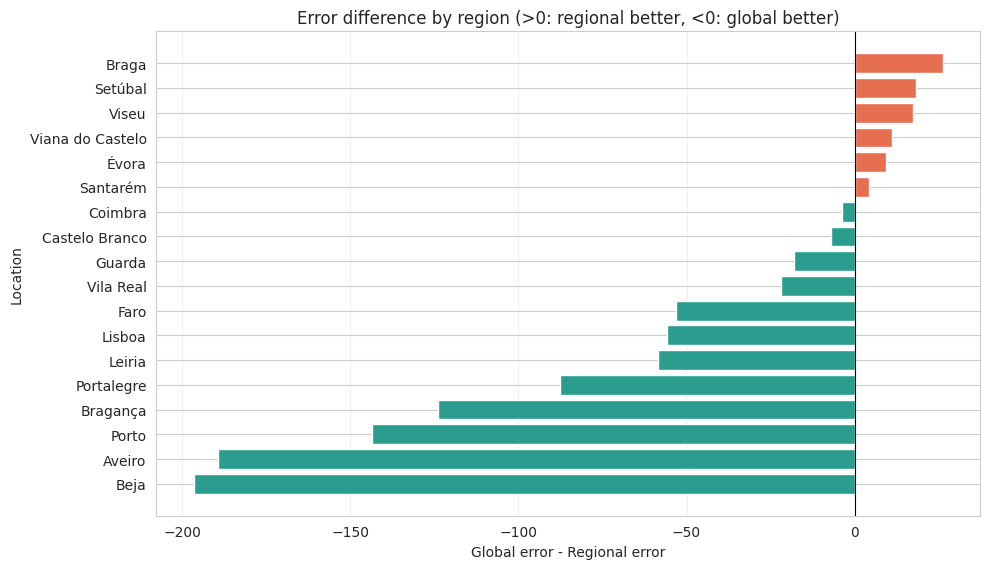

In [39]:
# Region-by-region comparison: where each strategy wins or loses
loc_eval = eval_df.groupby('location').agg(
    rows=('accident_count', 'count'),
    mean_actual_acc=('accident_count', 'mean'),
    total_vehicle_error_global=('vehicle_error_global', 'sum'),
    total_vehicle_error_regional=('vehicle_error_regional', 'sum'),
    under_rate_global=('under_global', 'mean'),
    under_rate_regional=('under_regional', 'mean')
).reset_index()

loc_eval['global_minus_regional_error'] = (
    loc_eval['total_vehicle_error_global'] - loc_eval['total_vehicle_error_regional']
)
loc_eval['winner'] = np.where(
    loc_eval['total_vehicle_error_global'] < loc_eval['total_vehicle_error_regional'],
    'Global',
    'Regional'
)
loc_eval = loc_eval.sort_values('global_minus_regional_error', ascending=False)

print('REGION-LEVEL PERFORMANCE COMPARISON')
print('=' * 90)
print(
    loc_eval[[
        'location', 'rows', 'mean_actual_acc',
        'total_vehicle_error_global', 'total_vehicle_error_regional',
        'global_minus_regional_error', 'under_rate_global', 'under_rate_regional', 'winner'
    ]].round(3).to_string(index=False)
 )

fig, ax = plt.subplots(figsize=(10, 5.8))
plot_df = loc_eval.sort_values('global_minus_regional_error', ascending=True)
ax.barh(
    plot_df['location'],
    plot_df['global_minus_regional_error'],
    color=['#e76f51' if x > 0 else '#2a9d8f' for x in plot_df['global_minus_regional_error']]
 )
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Global error - Regional error')
ax.set_ylabel('Location')
ax.set_title('Error difference by region (>0: regional better, <0: global better)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [40]:
# Final compact objective metrics (easy-to-read)
# Vehicle Error is the primary business objective.
# This table compares WITH uplift vs WITHOUT uplift.

actual_veh = 3 * eval_df['accident_count']

global_raw_veh = 3 * eval_df['pred_global_raw']
global_adj_veh = 3 * eval_df['pred_global']
regional_raw_veh = 3 * eval_df['pred_regional_raw']
regional_adj_veh = 3 * eval_df['pred_regional']

summary_simple = pd.DataFrame([
    {
        'Model': 'Global',
        'Mode': 'No uplift',
        'Total Vehicle Error': (actual_veh - global_raw_veh).abs().sum(),
        'Mean Vehicle Error': (actual_veh - global_raw_veh).abs().mean(),
        'Median Vehicle Error': (actual_veh - global_raw_veh).abs().median(),
        'P90 Vehicle Error': (actual_veh - global_raw_veh).abs().quantile(0.90),
        'Underestimation Rate': (eval_df['pred_global_raw'] < eval_df['accident_count']).mean(),
        'Total Actual Vehicles': actual_veh.sum(),
        'Total Pred Vehicles': global_raw_veh.sum()
    },
    {
        'Model': 'Global',
        'Mode': 'With uplift',
        'Total Vehicle Error': (actual_veh - global_adj_veh).abs().sum(),
        'Mean Vehicle Error': (actual_veh - global_adj_veh).abs().mean(),
        'Median Vehicle Error': (actual_veh - global_adj_veh).abs().median(),
        'P90 Vehicle Error': (actual_veh - global_adj_veh).abs().quantile(0.90),
        'Underestimation Rate': (eval_df['pred_global'] < eval_df['accident_count']).mean(),
        'Total Actual Vehicles': actual_veh.sum(),
        'Total Pred Vehicles': global_adj_veh.sum()
    },
    {
        'Model': 'Regional',
        'Mode': 'No uplift',
        'Total Vehicle Error': (actual_veh - regional_raw_veh).abs().sum(),
        'Mean Vehicle Error': (actual_veh - regional_raw_veh).abs().mean(),
        'Median Vehicle Error': (actual_veh - regional_raw_veh).abs().median(),
        'P90 Vehicle Error': (actual_veh - regional_raw_veh).abs().quantile(0.90),
        'Underestimation Rate': (eval_df['pred_regional_raw'] < eval_df['accident_count']).mean(),
        'Total Actual Vehicles': actual_veh.sum(),
        'Total Pred Vehicles': regional_raw_veh.sum()
    },
    {
        'Model': 'Regional',
        'Mode': 'With uplift',
        'Total Vehicle Error': (actual_veh - regional_adj_veh).abs().sum(),
        'Mean Vehicle Error': (actual_veh - regional_adj_veh).abs().mean(),
        'Median Vehicle Error': (actual_veh - regional_adj_veh).abs().median(),
        'P90 Vehicle Error': (actual_veh - regional_adj_veh).abs().quantile(0.90),
        'Underestimation Rate': (eval_df['pred_regional'] < eval_df['accident_count']).mean(),
        'Total Actual Vehicles': actual_veh.sum(),
        'Total Pred Vehicles': regional_adj_veh.sum()
    }
]).round(3)

summary_simple['Vehicle Bias (Pred-Actual)'] = (
    summary_simple['Total Pred Vehicles'] - summary_simple['Total Actual Vehicles']
).round(3)

# Improvement view: positive means uplift reduced vehicle error
comparison = []
for model_name in ['Global', 'Regional']:
    no_row = summary_simple[(summary_simple['Model'] == model_name) & (summary_simple['Mode'] == 'No uplift')].iloc[0]
    up_row = summary_simple[(summary_simple['Model'] == model_name) & (summary_simple['Mode'] == 'With uplift')].iloc[0]
    comparison.append({
        'Model': model_name,
        'Vehicle Error Improvement (NoUplift - Uplift)': no_row['Total Vehicle Error'] - up_row['Total Vehicle Error'],
        'Underestimation Rate Change (Uplift - NoUplift)': up_row['Underestimation Rate'] - no_row['Underestimation Rate']
    })
comparison_df = pd.DataFrame(comparison).round(3)

best_model = summary_simple.sort_values('Total Vehicle Error').iloc[0]

print('FINAL OBJECTIVE METRICS (WITH VS WITHOUT UPLIFT)')
print('=' * 90)
print(summary_simple.to_string(index=False))

print('\nUPLIFT IMPACT SUMMARY')
print('=' * 90)
print(comparison_df.to_string(index=False))

print('\nBest setup by Total Vehicle Error:')
print(f"{best_model['Model']} - {best_model['Mode']}")

FINAL OBJECTIVE METRICS (WITH VS WITHOUT UPLIFT)
   Model        Mode  Total Vehicle Error  Mean Vehicle Error  Median Vehicle Error  P90 Vehicle Error  Underestimation Rate  Total Actual Vehicles  Total Pred Vehicles  Vehicle Bias (Pred-Actual)
  Global   No uplift             2989.786              16.610                10.879             38.486                 0.439                  10698            12052.172                    1354.172
  Global With uplift             3470.414              19.280                12.042             45.231                 0.200                  10698            13402.172                    2704.172
Regional   No uplift             3805.903              21.144                14.939             47.503                 0.300                  10698            13122.121                    2424.121
Regional With uplift             4342.885              24.127                17.207             52.155                 0.200                  10698            1419